# Images and Convolutional Neural Networks

* Images -> Pixels -> Picture elements

* Each pixel contains color information

* In this section, we will use the Kaggle [Cloud Photos dataset](https://www.kaggle.com/datasets/jockeroika/clouds-photos/data), acknowledging the authors and contributors. 

* Check out the ```clouds_train```, ```clouds_train``` and ```clouds_test``` folder structure in the ```data``` folder and the docs for ```ImageFolder``` function.

* Torchvision: Officially computer vision library for PyTorch.

## 0 - Import Libraries

In [17]:
import torchvision, torch
print(f'PyTorch version: {torch.__version__}')
print(f'Torchvision version: {torchvision.__version__}')

PyTorch version: 2.8.0+cu128
Torchvision version: 0.23.0+cu128


In [18]:
import glob
import importlib
import os
import sys
import warnings

import matplotlib.pyplot as plt
from PIL import Image
import polars as pl
import torch
from torch.amp import autocast, GradScaler
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchmetrics import MetricCollection, Accuracy, Precision, Recall, F1Score
from torchvision.datasets import ImageFolder
from torchvision import transforms
import torchvision.transforms.functional as F
from tqdm import tqdm

import scripts.dl_custom_classes as dlclasses

In [19]:
warnings.filterwarnings("ignore")
importlib.reload(dlclasses)

<module 'scripts.dl_custom_classes' from '/home/devenv/Projects/deep-learning-with-pytorch/01-intermediate-dl/scripts/dl_custom_classes.py'>

## 1 - Cloud Image Example

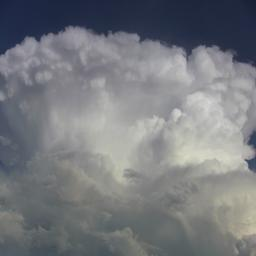

In [20]:
img_path = r'/home/devenv/Projects/deep-learning-with-pytorch/01-intermediate-dl/data/clouds_train/cumulonimbus clouds/c055e7211864fa6b07e07b87bb4ecbe4.jpg'
img = Image.open(img_path)
img.show()

## 2 - Training Transformations

Adding random transformations to the original images is a common technique know as **data augmentation**.

- Horizontal flip
- Random rotation
- Auto contrats adjustment
- Parse each image to Tensor
- Resize each image to 64 x 64

In [21]:
train_transforms = transforms.Compose([
    transforms.Resize(size=(128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(45), # Data Augmentation
    transforms.RandomAutocontrast(),
    transforms.ToTensor(),    
    # transforms.Normalize(
    #     mean=[0.485, 0.456, 0.406],
    #     std=[0.229, 0.224, 0.225]
    #)
])

Transformed training image example:

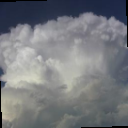

In [22]:
img_transformed = train_transforms(img)
img_pil = F.to_pil_image(img_transformed)
img_pil.show()

In [23]:
train_dataset = ImageFolder(
    root=r'/home/devenv/Projects/deep-learning-with-pytorch/01-intermediate-dl/data/clouds_train',
    transform=train_transforms
)

train_dataloader = DataLoader(
    dataset=train_dataset,
    shuffle=True,
    batch_size=10
)

Data sample:

In [24]:
image, label = next(iter(train_dataloader))
print(image.shape)
print(label)

# 10 for batch size of 10
# 3 for the three color channels
# 128 by 128 pixels: height and width.

torch.Size([10, 3, 128, 128])
tensor([0, 3, 6, 4, 6, 4, 6, 3, 4, 1])


To display a color images like this, it must be rearrange so the height and width come before the channels.

torch.Size([128, 128, 3])


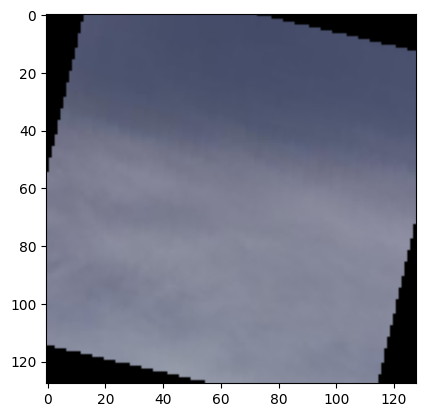

In [25]:
single_image = image[0]  # Shape: [3, 128, 128]
single_label = label[0]  # Single label

single_image = single_image.squeeze().permute(1, 2, 0)
print(single_image.shape)
plt.imshow(single_image)
plt.show()

## 3 - Validation and Test Transformations

In [26]:
test_transforms = transforms.Compose([
    transforms.Resize(size=(128, 128)),
    transforms.ToTensor(),    
    # transforms.Normalize(
    #     mean=[0.485, 0.456, 0.406],
    #     std=[0.229, 0.224, 0.225]
    # )
])

Validation dataset and dataloader:

In [27]:
valid_dataset = ImageFolder(
    root=r'/home/devenv/Projects/deep-learning-with-pytorch/01-intermediate-dl/data/clouds_validation',
    transform=test_transforms
)

valid_dataloader = DataLoader(
    dataset=valid_dataset,
    shuffle=True,
    batch_size=10
)

Test dataset and dataloader:

In [28]:
test_dataset = ImageFolder(
    root=r'/home/devenv/Projects/deep-learning-with-pytorch/01-intermediate-dl/data/clouds_test',
    transform=test_transforms
)

test_dataloader = DataLoader(
    dataset=test_dataset,
    shuffle=True,
    batch_size=10
)

## 4 - Convolutional Neural Networks Basics

 Convolutional Neural Networks (CNN) - Core Concepts:

Input Representation
* **Images classification**: Task of assigning labels to images based on their content
* **Pixel**: Basic unit of a digital image with intensity values
* **Matrices n1 x n2**: Images represented as 2D arrays (grayscale) or 3D tensors (RGB with channels)

Convolutional Layer
* **Convolution process**: Mathematical operation that slides filters over input to extract features
* **Filter or kernel**: Small matrix of learnable weights that detects specific patterns (edges, textures)
* **Feature map (activation map)**: Output produced when a filter is applied across the input
* **Padding**: Adding zeros around input borders; same padding keeps output size equal to input
* **Stride**: Step size for moving the filter; larger stride = smaller output
* **Receptive field**: Region of input that influences a particular feature in the output

Pooling Layer
* **Subsampling layer (pooling)**: Reduces spatial dimensions while retaining important features
* **Max pooling**: Takes maximum value from each pooling window
* **Local invariance**: Small translations in input don't drastically change output
* **Reduce overfitting**: Pooling adds robustness and decreases parameters

Architecture Components
* **Depth (number of filters)**: How many different features are extracted at each layer
* **Fully connected layer**: Final layers that perform classification using extracted features
* **Activation function**: Non-linearity (ReLU, sigmoid) applied after convolutions
* **Flattening**: Converting 2D feature maps to 1D vector before fully connected layers

Taker from Machine Learning with PyTorch and Scikit-Learn, pag 474.  
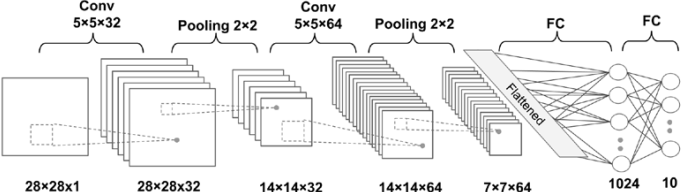

## 5 - Training, Validation and Test Sets

In [29]:
folder_path = r'/home/devenv/Projects/deep-learning-with-pytorch/01-intermediate-dl/data'
def count_images(folder_path: str) -> pl.DataFrame:
    data = []
    for i in ['clouds_train', 'clouds_validation', 'clouds_test']:
        path = os.path.join(folder_path, i)
        for name in sorted(os.listdir(path)):
            second_folder = os.path.join(path, name)
            row={'category': name, 'images': len(glob.glob(f'{second_folder}/*.jpg')), 'base': i}
            data.append(row)
    df = (
        pl.DataFrame(data=data)
        .pivot(on=['base'], index=['category'], values=['images'])
    )
    return df

count_images(folder_path=folder_path)

category,clouds_train,clouds_validation,clouds_test
str,i64,i64,i64
"""cirriform clouds""",86,27,30
"""clear sky""",75,19,30
"""cumulonimbus clouds""",17,3,5
"""cumulus clouds""",126,37,48
"""high cumuliform clouds""",163,33,40
"""stratiform clouds""",60,14,15
"""stratocumulus clouds""",76,21,35


## 6 - Training Image Classifier

Loss functions:

- Binary classification: binary cross-entropy (BCE) loss.
- Multi-class classification: cross-entropy loss

In [30]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
net = dlclasses.MyCNN(num_classes=7).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(params=net.parameters(), lr=0.0001)

### 6.1 - Option A: Single Training Loop

Running a single training loop to compute the loos per epoch.

In [31]:
for epoch in range(2):
    running_loss = 0.0
    for images, labels in train_dataloader:
        optimizer.zero_grad()
        outputs = net(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    epoch_loss = running_loss / len(train_dataloader)
    print(f'Epoch {epoch + 1}, Loss: {epoch_loss:.4f}')

Epoch 1, Loss: 1.8335
Epoch 2, Loss: 1.7487


### 6.2 - Option B: Train and Validation Loop

Training and validation loop usign accuracy metric.
Adapted from Machine Learning with PyTorch and Scikit-Learn (page 479)

In [ ]:
def train_cnn(
    model,  num_epochs,  train_dataloader,  valid_dataloader,  loss_function, optimizer, device
) -> tuple[list[float], list[float], list[float], list[float]]:
    
    loss_hist_train = [0.0] * num_epochs
    accuracy_hist_train = [0.0] * num_epochs
    loss_hist_valid = [0.0] * num_epochs
    accuracy_hist_valid = [0.0] * num_epochs

    epoch_bar = tqdm(range(num_epochs), file=sys.stdout, dynamic_ncols=False)
    for epoch in epoch_bar:
        model.train()
        for images, labels in train_dataloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            pred = model(images)
            loss = loss_function(pred, labels)
            loss.backward()
            optimizer.step()
            loss_hist_train[epoch] += loss.item() * labels.size(0)
            is_correct = (torch.argmax(pred, dim=1) == labels).float()
            accuracy_hist_train[epoch] += is_correct.sum().item()
        
        loss_hist_train[epoch] /= len(train_dataloader.dataset)
        accuracy_hist_train[epoch] /= len(train_dataloader.dataset)

        model.eval()
        with torch.no_grad():
            for images, labels in valid_dataloader:
                images, labels = images.to(device), labels.to(device)
                pred = model(images)
                loss = loss_function(pred, labels)
                loss_hist_valid[epoch] += loss.item() * labels.size(0)
                is_correct = (torch.argmax(pred, dim=1) == labels).float()
                accuracy_hist_valid[epoch] += is_correct.sum().item()

        loss_hist_valid[epoch] /= len(valid_dataloader.dataset)
        accuracy_hist_valid[epoch] /= len(valid_dataloader.dataset)

        tqdm.write(
            f'Epoch {epoch + 1} Accuracy: {accuracy_hist_train[epoch]:.4f} '
            f'Validation Accuracy: {accuracy_hist_valid[epoch]:.4f}',
            file=sys.stdout
        )
        
    return loss_hist_train, loss_hist_valid, accuracy_hist_train, accuracy_hist_valid


In [ ]:
# torch.manual_seed(1)
hist = train_cnn(
    model=net,
    num_epochs=10,
    train_dataloader=train_dataloader,
    valid_dataloader=valid_dataloader,
    loss_function=criterion,
    optimizer=optimizer,
    device=device
)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1 Accuracy: 0.2239 Validation Accuracy: 0.2143
Epoch 2 Accuracy: 0.2919 Validation Accuracy: 0.2468
Epoch 3 Accuracy: 0.3201 Validation Accuracy: 0.3831
Epoch 4 Accuracy: 0.3698 Validation Accuracy: 0.3766
Epoch 5 Accuracy: 0.3682 Validation Accuracy: 0.5065
Epoch 6 Accuracy: 0.3781 Validation Accuracy: 0.4481
Epoch 7 Accuracy: 0.4561 Validation Accuracy: 0.4545
Epoch 8 Accuracy: 0.4428 Validation Accuracy: 0.4481
Epoch 9 Accuracy: 0.4561 Validation Accuracy: 0.4935
Epoch 10 Accuracy: 0.4710 Validation Accuracy: 0.5130
100%|██████████| 10/10 [04:34<00:00, 27.42s/it]


### 6.3 - Option C: Use Precision and Recall Metrics

Usign another metricS like Precision and Recall from torchmetrics library in the training and validation loop

In [ ]:
def train_cnn_metrics(
    model, 
    num_epochs, 
    train_dataloader, 
    valid_dataloader, 
    loss_function, 
    optimizer, 
    device,
):

    train_precision = Precision(task="multiclass", num_classes=7, average="macro").to(device)
    val_precision = train_precision.clone().to(device)

    train_recall = Recall(task="multiclass", num_classes=7, average="macro")
    val_recall = train_recall.clone().to(device)

    epoch_bar = tqdm(range(num_epochs), file=sys.stdout, dynamic_ncols=False)

    for epoch in epoch_bar:

        train_precision.reset()
        train_recall.reset()
        val_precision.reset()
        val_recall.reset()

        # Training Phase
        model.train()
        train_loss = 0.0

        for images, labels in train_dataloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_function(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            train_precision.update(preds, labels)
            train_recall.update(preds, labels)

        avg_train_loss = train_loss / len(train_dataloader)
        precision_results = train_precision.compute()
        recall_results = train_recall.compute()

        # Evaluation Phase
        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for images, labels in valid_dataloader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = loss_function(outputs, labels)
                val_loss += loss.item()

                preds = torch.argmax(outputs, dim=1)
                val_precision.update(preds, labels)
                val_recall.update(preds, labels)

        avg_val_loss = val_loss / len(valid_dataloader)
        val_precision_results = val_precision.compute()
        val_recall_results = val_recall.compute()

        tqdm.write(
            f"Epoch {epoch + 1} \n"
            f"  Train: Loss {avg_train_loss:.4f}, Precision {precision_results:.4f}, Recall {recall_results:.4f}\n"
            f"  Val:   Loss {avg_val_loss:.4f}, Precision {val_precision_results:.4f}, Recall {val_recall_results:.4f}"
        )

In [ ]:
# torch.manual_seed(1)
hist = train_cnn_metrics(
    model=net,
    num_epochs=5,
    train_dataloader=train_dataloader,
    valid_dataloader=valid_dataloader,
    loss_function=criterion,
    optimizer=optimizer,
    device=device
)

### 6.4 - Option D: Early Stopping

Add more metrics, early stopping check and save the best model based on F1 score.

In [ ]:
def train_model(
    model,
    train_dataloader,
    valid_dataloader,
    num_classes: int,
    loss_function,
    optimizer,
    device,
    num_epochs: int = 30,
    patience: int = 5,
    save_path: str = "best_model.pth"
):

    # Mixed precision scaler
    scaler = GradScaler("cuda")

    # Metrics
    metric_collection = MetricCollection({
        "accuracy": Accuracy(task="multiclass", num_classes=num_classes),
        "precision": Precision(task="multiclass", num_classes=num_classes, average="macro"),
        "recall": Recall(task="multiclass", num_classes=num_classes, average="macro"),
        "f1": F1Score(task="multiclass", num_classes=num_classes, average="macro")
    }).to(device)

    train_metrics = metric_collection.clone(prefix="train_")
    val_metrics = metric_collection.clone(prefix="val_")

    best_val_f1 = 0 # Due imbalance data
    patience_counter = 0

    epoch_bar = tqdm(range(num_epochs), file=sys.stdout, dynamic_ncols=False)
    
    for epoch in epoch_bar:

        # Training Phase
        model.train()
        train_metrics.reset()
        total_train_loss = 0.0

        for images, labels in train_dataloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            with autocast('cuda'):
                outputs = model(images)
                loss = loss_function(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_train_loss += loss.item()

            preds = outputs.argmax(dim=1)
            train_metrics.update(preds, labels)

        avg_train_loss = total_train_loss / len(train_dataloader)
        train_results = train_metrics.compute()

        # Validation Phase
        model.eval()
        val_metrics.reset()
        total_val_loss = 0.0

        with torch.no_grad():
            for images, labels in valid_dataloader:
                images, labels = images.to(device), labels.to(device)

                with autocast('cuda'):
                    outputs = model(images)
                    loss = loss_function(outputs, labels)

                total_val_loss += loss.item()

                preds = outputs.argmax(dim=1)
                val_metrics.update(preds, labels)

        avg_val_loss = total_val_loss / len(valid_dataloader)
        val_results = val_metrics.compute()

        tqdm.write(
            f"Epoch {epoch + 1}\n"
            f"  Train: Loss {avg_train_loss:.4f}, Acc {train_results['train_accuracy']:.4f}, "
            f"Prec {train_results['train_precision']:.4f}, Rec {train_results['train_recall']:.4f}, "
            f"F1 {train_results['train_f1']:.4f}\n"
            f"  Val:   Loss {avg_val_loss:.4f}, Acc {val_results['val_accuracy']:.4f}, "
            f"Prec {val_results['val_precision']:.4f}, Rec {val_results['val_recall']:.4f}, "
            f"F1 {val_results['val_f1']:.4f}"
        )

        # Early Stopping + Checkpoint
        if val_results['val_f1'] > best_val_f1:
            best_val_f1 = val_results['val_f1']
            patience_counter = 0
            best_epoch = epoch + 1
            torch.save(model.state_dict(), save_path)
        else:
            patience_counter += 1

            if patience_counter >= patience:
                tqdm.write(f"\n Early stopping triggered. Best epoch: {best_epoch} \n")
                break


In [34]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
net = dlclasses.MyCNN(num_classes=7).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(params=net.parameters(), lr=0.001)

In [ ]:
train_model(
    model=net,
    train_dataloader=train_dataloader,
    valid_dataloader=valid_dataloader,
    num_classes=7,
    loss_function=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=1000,
    patience=80,
    save_path=fr"/home/devenv/Projects/deep-learning-with-pytorch/01-intermediate-dl/models/best_cnn.pth"
)


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1                                 
  Train: Loss 2.2212, Acc 0.2305, Prec 0.1373, Rec 0.1410, F1 0.1165
  Val:   Loss 1.8107, Acc 0.2143, Prec 0.0306, Rec 0.1429, F1 0.0504
Epoch 2                                           
  Train: Loss 1.8199, Acc 0.3068, Prec 0.2661, Rec 0.1740, F1 0.1180
  Val:   Loss 1.7318, Acc 0.2727, Prec 0.0991, Rec 0.1733, F1 0.1177
Epoch 3                                           
  Train: Loss 1.7249, Acc 0.2886, Prec 0.1855, Rec 0.1827, F1 0.1582
  Val:   Loss 1.6742, Acc 0.3701, Prec 0.1662, Rec 0.2740, F1 0.2063
Epoch 4                                           
  Train: Loss 1.6635, Acc 0.3002, Prec 0.1991, Rec 0.1927, F1 0.1734
  Val:   Loss 1.5270, Acc 0.3571, Prec 0.1688, Rec 0.2921, F1 0.2072
Epoch 5                                           
  Train: Loss 1.6518, Acc 0.3085, Prec 0.2276, Rec 0.2162, F1 0.2061
  Val:   Loss 1.6046, Acc 0.3117, Prec 0.1280, Rec 0.2535, F1 0.1687
Epoch 6                                           
  Train: Loss 

## 7 - Evaluating Image Classifier

Loading a custom pretrain model:

In [35]:
trained_net = dlclasses.MyCNN(num_classes=7).to(device)
state_dict = torch.load(f=r'/home/devenv/Projects/deep-learning-with-pytorch/01-intermediate-dl/models/best_cnn.pth')
trained_net.load_state_dict(state_dict)

<All keys matched successfully>

### 7.1 - Overall Results

In [36]:
eval_precision = Precision(task='multiclass', num_classes=7, average='macro')
eval_recall = Recall(task='multiclass', num_classes=7, average='macro')

trained_net.eval()
with torch.no_grad():
    for images, labels in test_dataloader:
        outputs = trained_net(images)
        _, preds = torch.max(outputs, 1)
        eval_precision(preds, labels)
        eval_recall(preds, labels)
precision = eval_precision.compute()
recall = eval_recall.compute()

print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')

Precision: 0.8031
Recall: 0.8079


### 7.2 - Per Class Test Metrics

In [41]:
eval_recall = Recall(task='multiclass', num_classes=7, average=None)

trained_net.eval()
with torch.no_grad():
    for images, labels in test_dataloader:
        outputs = trained_net(images)
        _, preds = torch.max(outputs, 1)
        eval_recall(preds, labels)
recall = eval_recall.compute()

{
    k: round(recall[v].item(), 4)
    for k, v
    in test_dataset.class_to_idx.items()
}

{'cirriform clouds': 0.8,
 'clear sky': 1.0,
 'cumulonimbus clouds': 0.8,
 'cumulus clouds': 0.6042,
 'high cumuliform clouds': 0.775,
 'stratiform clouds': 0.9333,
 'stratocumulus clouds': 0.7429}